In [ ]:
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
imagesdf = pd.read_csv("data/image_index.csv")


All autofluorescence files have a scaling of 0.62 pixels per um. 

While all Nissl files have a scaling of 0.576 pixels per um, except B07_A2_S1 and B07_S1_S4, as these were made with the standard microscope, so these also have a scaling of 0.62 pixels per um. 

The autofluorescence files are unprocessed, while the Nissl were changed to a 16bit file and inverted. 
Again, exceptions are B07_A2_S1 and B07_S1_S4, which were processed via split channels>grayscale>invert.

In [2]:
nissldf = imagesdf[imagesdf['modality'] == 'nissl']
afdf = imagesdf[imagesdf['modality'] == 'autofluorescence']

In [3]:
afdf['Pixel size'] = 1/0.576

nissldf['Pixel size'] = 1/0.62

nissldf.loc[(nissldf['brain_id'] == 'B07') & (nissldf['region'] == 'A2') & (nissldf['section'] == 'S1') , 'Pixel size'] = 1/0.576
nissldf.loc[(nissldf['brain_id'] == 'B07') & (nissldf['region'] == 'S1') & (nissldf['section'] == 'S4') , 'Pixel size'] = 1/0.576

In [4]:
nissldf[(nissldf['brain_id'] == 'B07') & (nissldf['region'] == 'A2') & (nissldf['section'] == 'S1') ]['Pixel size'] = 1/0.576

C:\Users\P70089795\AppData\Local\Temp\ipykernel_19348\3845461704.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  nissldf[(nissldf['brain_id'] == 'B07') & (nissldf['region'] == 'A2') & (nissldf['section'] == 'S1') ]['Pixel size'] = 1/0.576


In [ ]:
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d , median_filter
from scipy.signal import savgol_filter
from scipy.ndimage import uniform_filter1d


def compute_normalized_profile(img):
    profile = np.mean(img, axis = 1)
    profile_norm = detrend_profile(profile, baseline_window = int(len(profile)/3))
    profile_res = resample_profile(profile_norm, n_bins = 500)
    profile_smooth = gaussian_filter1d(profile, 4)
    
    return profile_smooth

def resample_profile(profile: np.ndarray, n_bins: int = 100) -> np.ndarray:
    """Resample a 1D profile to n_bins equispaced depth points (0-100%)."""
    x_raw = np.linspace(0, 1, len(profile))
    x_norm = np.linspace(0, 1, n_bins)
    return interp1d(x_raw, profile, kind="quadratic")(x_norm)


def detrend_profile(profile, baseline_window):
    """Remove slowly varying background, then mean-normalize."""
    # estimate baseline with a wide moving average
    baseline = uniform_filter1d(profile.astype(float), size=baseline_window)
    # divide to correct for multiplicative staining variation
    corrected = profile / (baseline + 1e-6)
    # mean-normalize so profiles are comparable
    corrected = corrected / corrected.mean()
    return corrected


other ideas
- PCA on the profiles, then clustering based on biggest components
- scipy.stats.wasserstein_distance # earth movers distance
- dynamic time warping - from dtaidistance import dtw, dtw_ndim

In [6]:
# import skimage as ski
# radius = 15
# footprint = ski.morphology.disk(radius)
# local_otsu = ski.filters.rank.otsu(img, footprint)


# this would be adaptive thresholding to replicate the GLI

In [7]:
imagesdf['profile'] = imagesdf['file_path'].apply(lambda fp: compute_normalized_profile(tifffile.imread(fp)))

In [8]:
imagesdf['region'] = imagesdf['region'].apply(lambda a: a.upper())

In [9]:
imagesdf

,modality,brain_id,region,section,file_path,filename,subfolder,shape,dtype,axes,...,parse_status,suffix_tags,year,total_sections,thickness,magnification,exposure,channel,filter_code,profile
0,nissl,B07,A2,S1,C:\Users\P70089795\Documents\Cortical profiles...,B07_A2_S1_4x_4ms_nissl_50um_fused_cropped_crop...,B07_A2_cropped_edited,"(3815, 300)",uint16,YX,...,ok,4x_4ms_nissl_50um_fused_cropped_cropped_splitc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.1892169240711883, 0.1846002178123676, 0.196..."
1,nissl,B07,A2,S2,C:\Users\P70089795\Documents\Cortical profiles...,B07_A2_S2_cropped_16bit_inverted.tif,B07_A2_cropped_edited,"(3750, 300)",uint16,YX,...,ok,cropped_16bit_inverted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.44772719566351715, 0.4416905717095443, 0.44..."
2,nissl,B07,A2,S3,C:\Users\P70089795\Documents\Cortical profiles...,B07_A2_S3_cropped_16bit_inverted.tif,B07_A2_cropped_edited,"(3750, 300)",uint16,YX,...,ok,cropped_16bit_inverted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.3800265135933891, 0.3811151502032527, 0.381..."
3,nissl,B07,A2,S4,C:\Users\P70089795\Documents\Cortical profiles...,B07_A2_S4_cropped_16bit_inverted.tif,B07_A2_cropped_edited,"(3750, 300)",uint16,YX,...,ok,cropped_16bit_inverted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.4417663655801702, 0.4426674078257184, 0.442..."
4,nissl,B07,A2,S5,C:\Users\P70089795\Documents\Cortical profiles...,B07_A2_S5_cropped_16bit_inverted.tif,B07_A2_cropped_edited,"(3750, 300)",uint16,YX,...,ok,cropped_16bit_inverted,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[0.33515464811230716, 0.33128931488448604, 0.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,autofluorescence,B13,S1,R2,C:\Users\P70089795\Documents\Cortical profiles...,AF_LF_200um_B132024s1_R2of3_4x_1000ms_yellow_1...,B13_S1,"(2560, 300)",uint16,YX,...,ok,NaN,2024.0,3.0,200um,4x,1000ms,yellow,15126.0,"[0.7051926793457968, 0.7054162497147767, 0.705..."
135,autofluorescence,B13,S1,R3,C:\Users\P70089795\Documents\Cortical profiles...,AF_LF_200um_B132024s1_R3of3_4x_1000ms_yellow_1...,B13_S1,"(2284, 300)",uint16,YX,...,ok,NaN,2024.0,3.0,200um,4x,1000ms,yellow,15126.0,"[0.8311767195716684, 0.8670102536590276, 0.905..."
136,autofluorescence,B13,V1V2,R1,C:\Users\P70089795\Documents\Cortical profiles...,AF_LF_200um_B132024V1V2_R1of3_4x_100ms_yellow_...,B13_V1,"(2040, 300)",uint16,YX,...,ok,NaN,2024.0,3.0,200um,4x,100ms,yellow,15126.0,"[0.6783839892028252, 0.6819854073748965, 0.690..."
137,autofluorescence,B13,V1V2,R2,C:\Users\P70089795\Documents\Cortical profiles...,AF_LF_200um_B132024V1V2_R2of3_4x_1000ms_yellow...,B13_V1,"(1701, 300)",uint16,YX,...,ok,NaN,2024.0,3.0,200um,4x,1000ms,yellow,15126.0,"[0.5508603792394839, 0.5594509983915927, 0.573..."


In [10]:
imagesdf['bin'] = imagesdf['profile'].apply(lambda a: np.arange(len(a)))
images_long_df = imagesdf.explode(['profile', 'bin']).reset_index(drop=True)

In [11]:
images_long_df['bin'] = images_long_df['bin'].astype('float')

In [12]:
images_long_df['profile'] = images_long_df['profile'].astype('float')

In [ ]:
images_long_df.to_csv('data/profiles_long.csv', index=False)

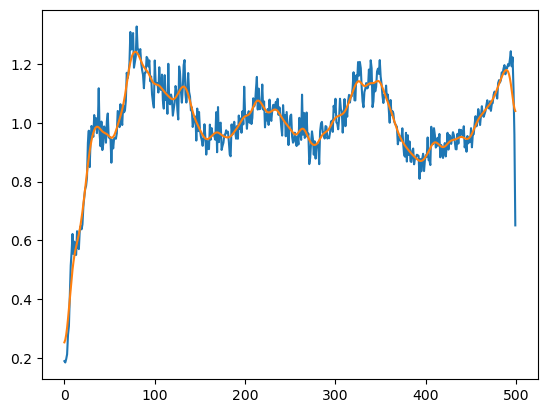

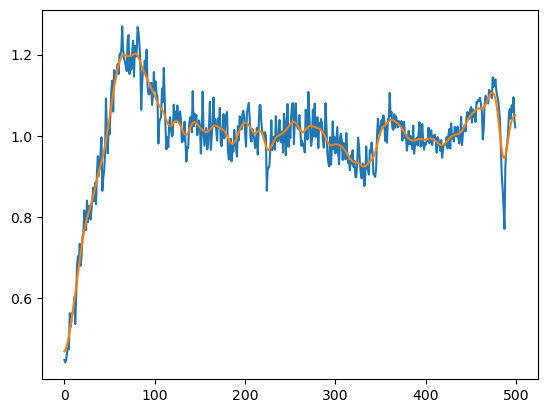

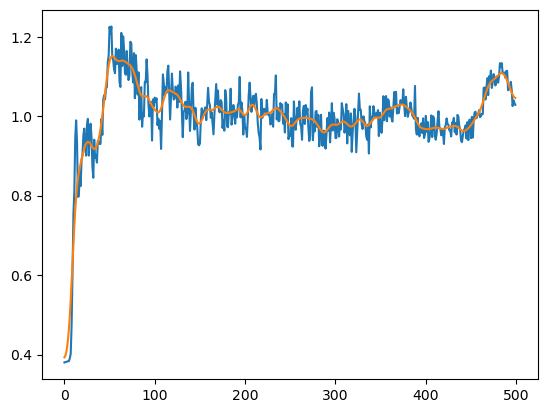

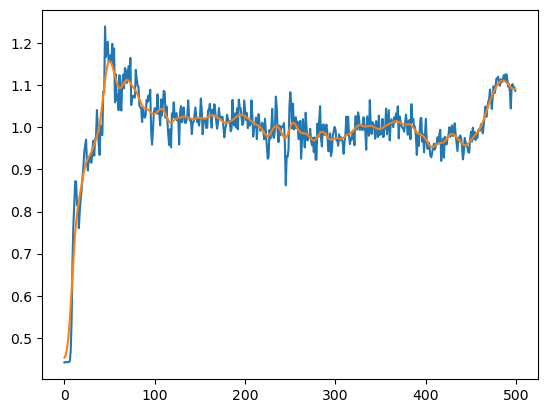

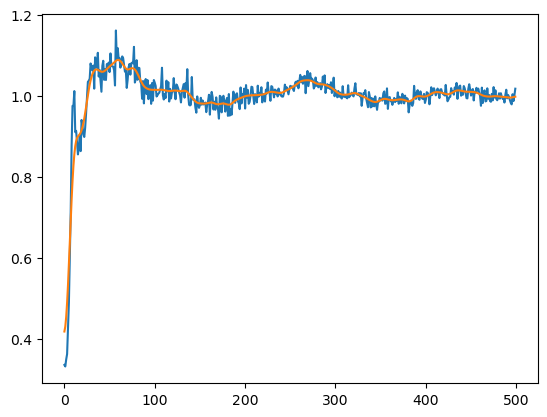

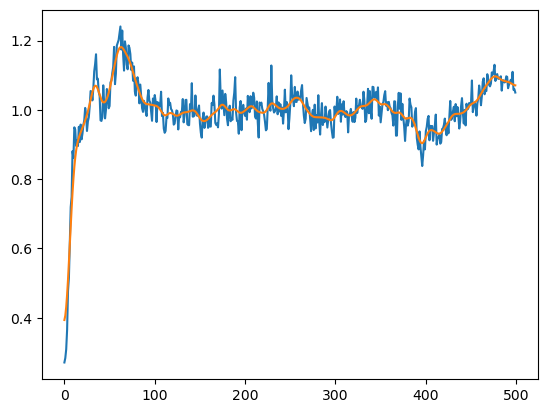

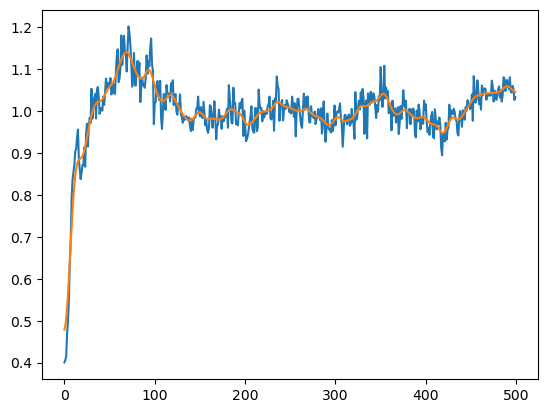

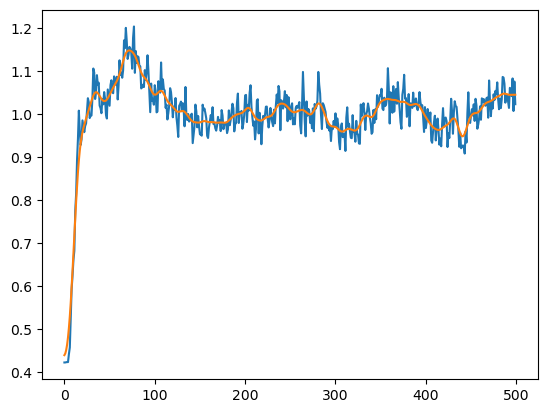

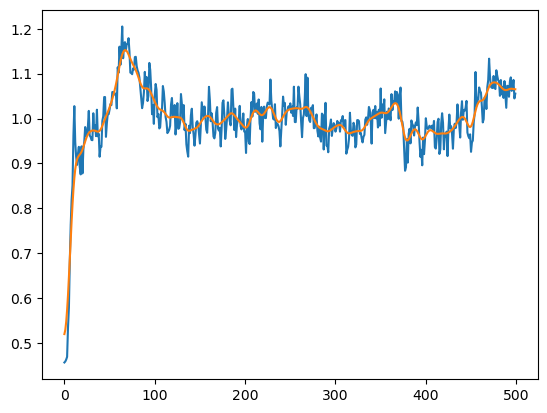

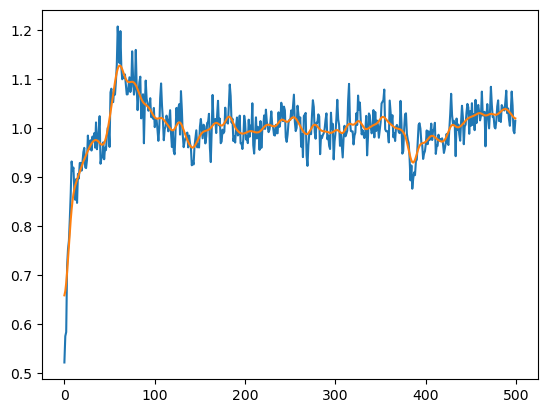

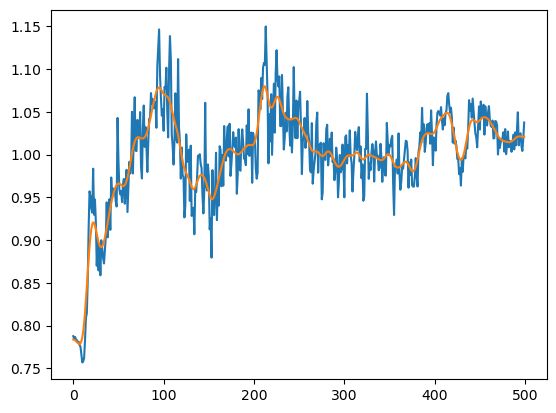

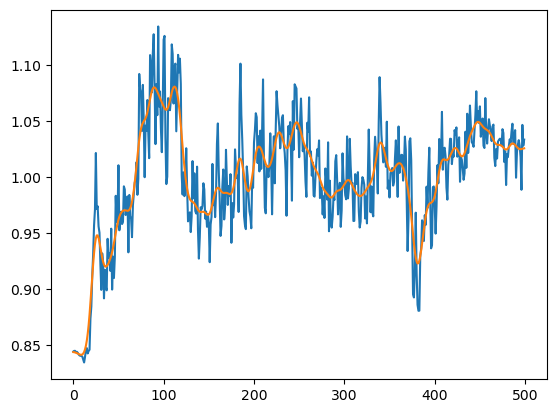

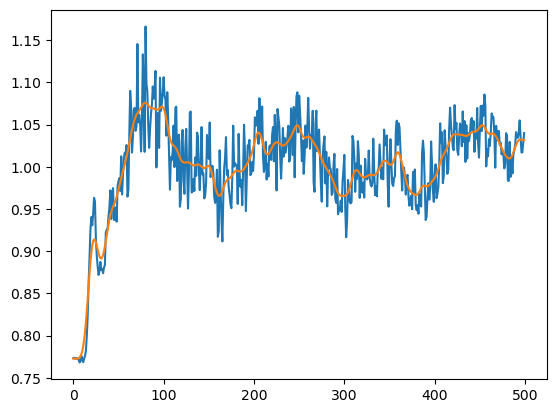

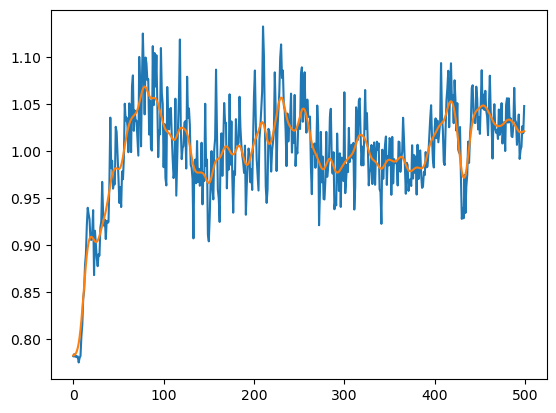

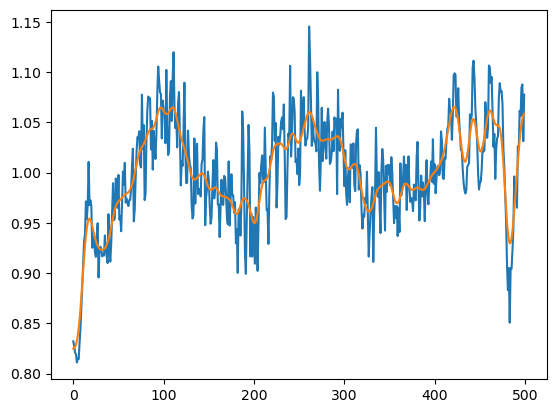

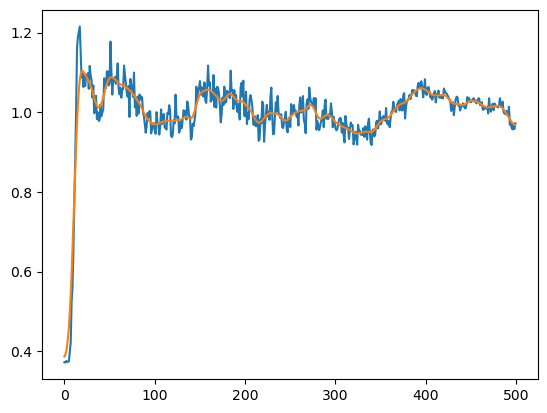

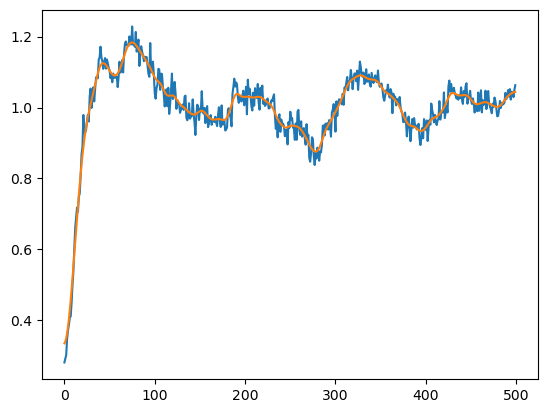

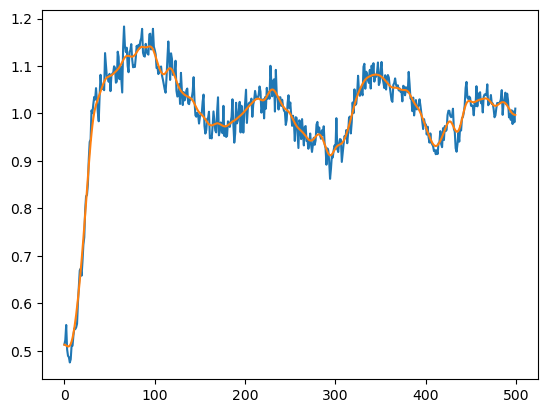

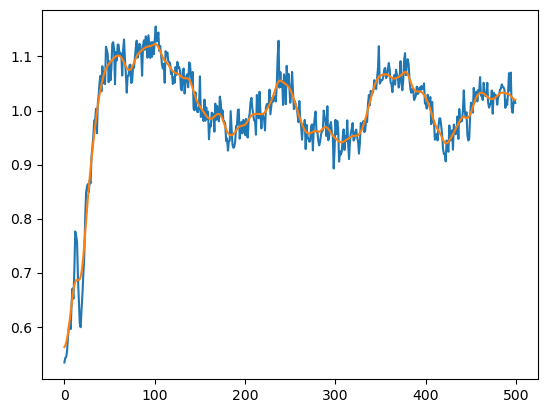

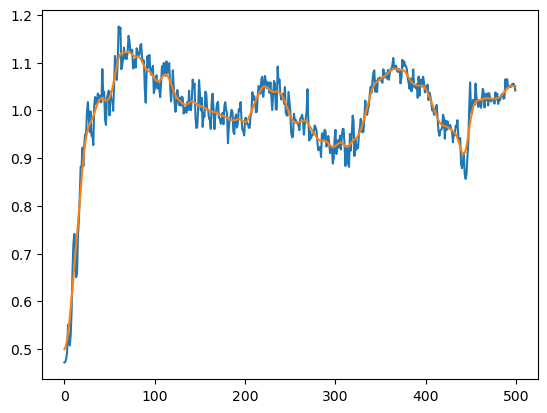

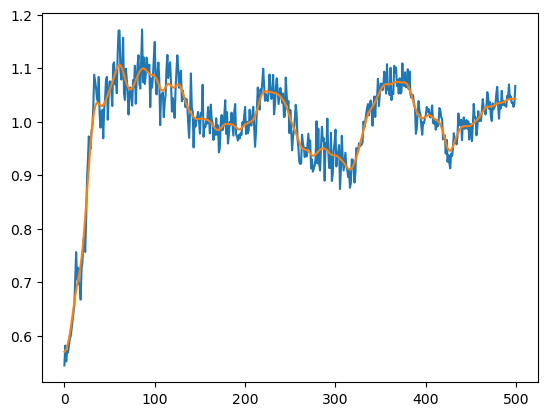

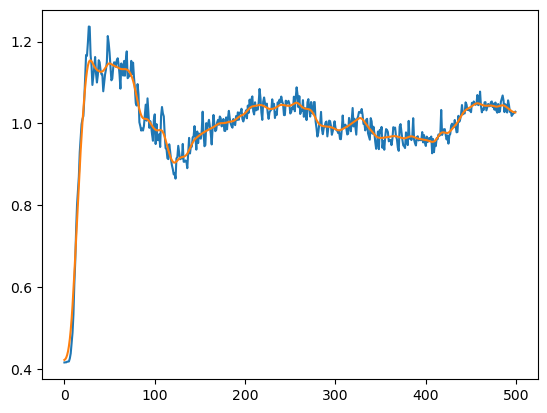

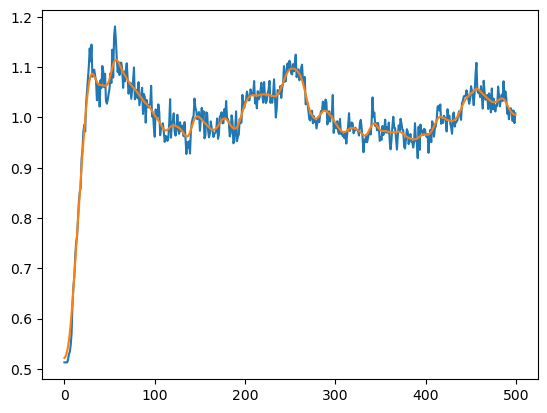

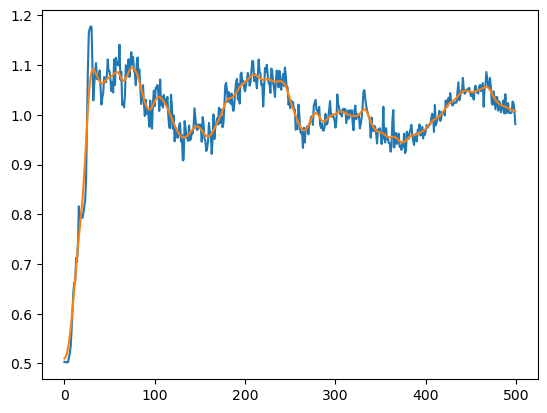

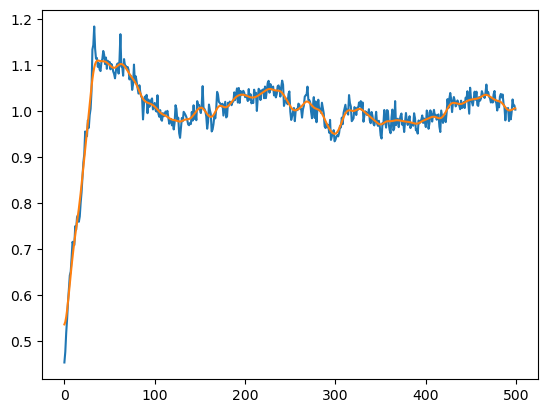

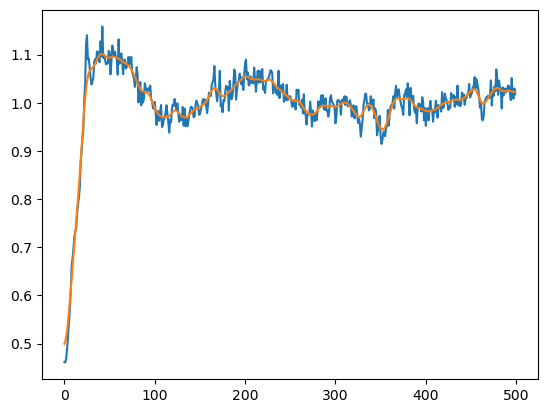

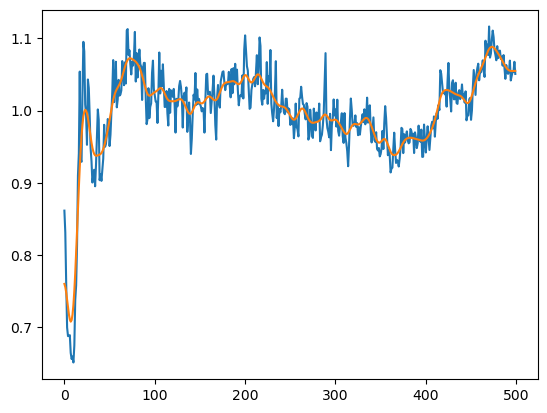

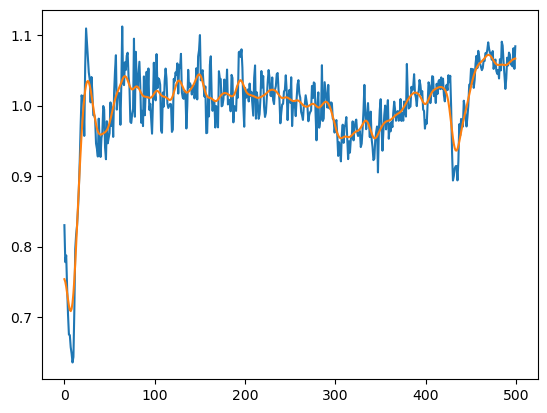

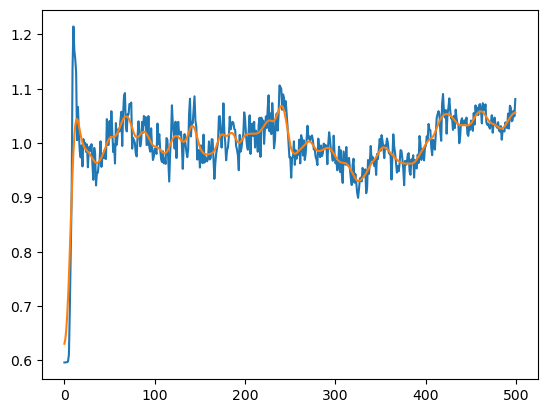

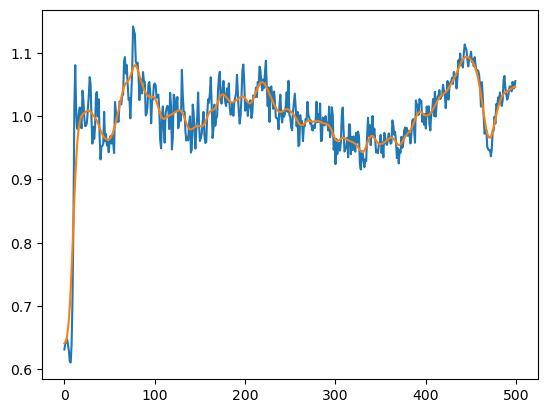

In [15]:
for profile in imagesdf['profile'][:30]:

    plt.plot(profile)
    #plt.plot(median_filter(profile, size=5))
    plt.plot(gaussian_filter1d(profile, 4))
    #plt.plot(savgol_filter(profile, window_length=11, polyorder=3))
    plt.show()
